In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb
import shap

# ── Load engineered features from Phase 3 ─────
PROCESSED = r"C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed"
df = pd.read_csv(f"{PROCESSED}\\features_ready.csv")

print(f"Dataset loaded: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nOriginal target distribution:")
print(df['on_time'].value_counts())
print(f"\n1 = On time  |  0 = Late")

Dataset loaded: (10999, 18)

Columns: ['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'on_time', 'high_care_calls', 'discount_tier', 'weight_category', 'is_high_value', 'is_repeat_customer', 'low_satisfaction']

Original target distribution:
on_time
1    6563
0    4436
Name: count, dtype: int64

1 = On time  |  0 = Late


In [2]:
# ── Define feature columns ─────────────────────
feature_cols = [
    'Warehouse_block',
    'Mode_of_Shipment',
    'Customer_care_calls',
    'Customer_rating',
    'Cost_of_the_Product',
    'Prior_purchases',
    'Product_importance',
    'Discount_offered',
    'Weight_in_gms',
    'high_care_calls',
    'is_high_value',
    'is_repeat_customer',
    'low_satisfaction',
    'discount_tier',
    'weight_category'
]

X = df[feature_cols]

# ── FLIP TARGET ────────────────────────────────
# Original: 1=on_time, 0=late
# Flipped:  1=late(failure), 0=on_time(success)
# Reason: XGBoost scale_pos_weight upweights class 1
# We want model to pay MORE attention to failures (late)
# So we make late = class 1 (positive class)
y = 1 - df['on_time']

print("Target after flipping:")
print(y.value_counts())
print("\n1 = Late/Failure (what we want to catch)")
print("0 = On time/Success")
print(f"\nFailure rate: {y.mean()*100:.2f}%")

# ── Train/Test split ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts())

Target after flipping:
on_time
0    6563
1    4436
Name: count, dtype: int64

1 = Late/Failure (what we want to catch)
0 = On time/Success

Failure rate: 40.33%

Training set: 8799 rows
Test set:     2200 rows

Class balance in training set:
on_time
0    5250
1    3549
Name: count, dtype: int64


In [3]:
# ── Class weight calculation ───────────────────
# class 0 = on_time (majority)
# class 1 = late/failure (minority — what we want to catch)
# scale_pos_weight = majority count / minority count
# This tells XGBoost: penalise missing a failure more than missing a success

n_success = (y_train == 0).sum()  # on_time count
n_failure = (y_train == 1).sum()  # late count
scale_weight = n_success / n_failure

print(f"On-time (class 0): {n_success}")
print(f"Late    (class 1): {n_failure}")
print(f"Scale weight:      {scale_weight:.2f}")
print(f"\nXGBoost will pay {scale_weight:.1f}x more attention to late deliveries ✅")

# ── Train XGBoost ──────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

print("\nTraining XGBoost model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print("Training complete!")

On-time (class 0): 5250
Late    (class 1): 3549
Scale weight:      1.48

XGBoost will pay 1.5x more attention to late deliveries ✅

Training XGBoost model...
Training complete!


MODEL EVALUATION REPORT
                  precision    recall  f1-score   support

     On Time (0)       0.89      0.50      0.64      1313
Late/Failure (1)       0.55      0.91      0.69       887

        accuracy                           0.67      2200
       macro avg       0.72      0.70      0.66      2200
    weighted avg       0.75      0.67      0.66      2200

ROC-AUC Score: 0.7257

Running 5-fold cross validation...
CV AUC Scores: [np.float64(0.9981), np.float64(0.9982), np.float64(0.6448), np.float64(0.489), np.float64(0.4972)]
Mean AUC:      0.7255
Std AUC:       0.2295


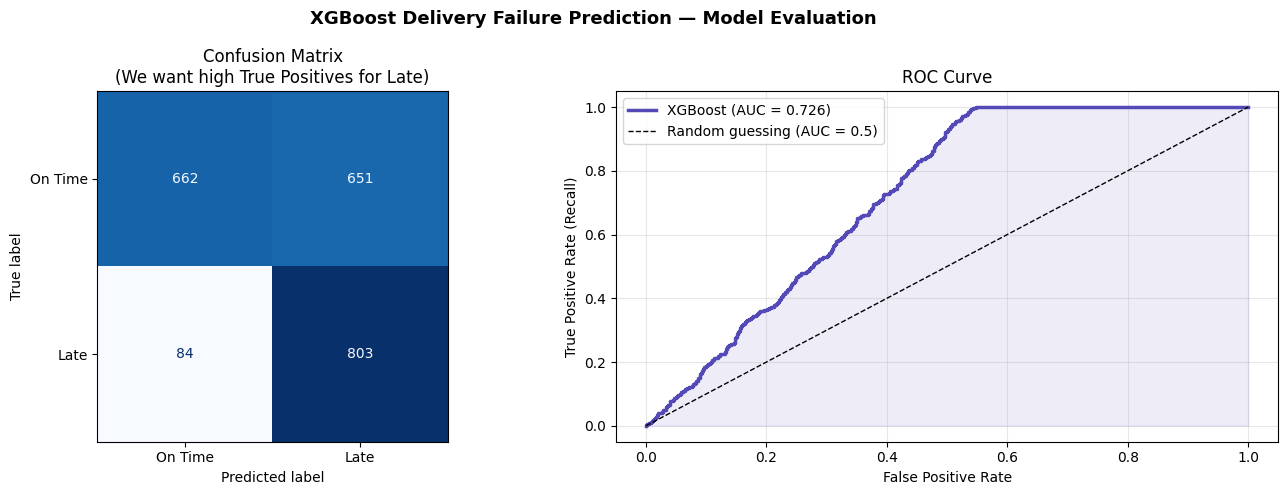


KEY METRICS SUMMARY
ROC-AUC:              0.7257
CV Mean AUC:          0.7255
Recall (Late orders): 0.9053  ← most important metric
Precision (Late):     0.5523

True Positives  (Late correctly caught):  803
False Negatives (Late missed by model):   84  ← these cost money
False Positives (On-time flagged as late): 651
True Negatives  (On-time correctly clear): 662


In [4]:
# ── Predictions ────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
# y_prob[:,1] = probability of being LATE (class 1)

# ── Classification Report ──────────────────────
print("=" * 55)
print("MODEL EVALUATION REPORT")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['On Time (0)', 'Late/Failure (1)']
))

auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

# ── 5-Fold Cross Validation ────────────────────
print("\nRunning 5-fold cross validation...")
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"CV AUC Scores: {[round(s,4) for s in cv_scores]}")
print(f"Mean AUC:      {cv_scores.mean():.4f}")
print(f"Std AUC:       {cv_scores.std():.4f}")

# ── Confusion Matrix + ROC Curve ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost Delivery Failure Prediction — Model Evaluation',
             fontsize=13, fontweight='bold')

# Left: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['On Time', 'Late']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(We want high True Positives for Late)')

# Right: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#534AB7', linewidth=2.5,
             label=f'XGBoost (AUC = {auc_score:.3f})')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1,
             label='Random guessing (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#534AB7')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED}\\chart7_model_evaluation.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key metric summary ─────────────────────────
print("\n" + "=" * 55)
print("KEY METRICS SUMMARY")
print("=" * 55)
print(f"ROC-AUC:              {auc_score:.4f}")
print(f"CV Mean AUC:          {cv_scores.mean():.4f}")
tn, fp, fn, tp = cm.ravel()
recall_failure = tp / (tp + fn)
precision_failure = tp / (tp + fp)
print(f"Recall (Late orders): {recall_failure:.4f}  ← most important metric")
print(f"Precision (Late):     {precision_failure:.4f}")
print(f"\nTrue Positives  (Late correctly caught):  {tp}")
print(f"False Negatives (Late missed by model):   {fn}  ← these cost money")
print(f"False Positives (On-time flagged as late): {fp}")
print(f"True Negatives  (On-time correctly clear): {tn}")

In [5]:
# ── Generate failure risk scores for all shipments ──
# probability of being LATE (class 1)
df['failure_risk_score'] = model.predict_proba(X)[:, 1]
df['predicted_outcome']  = model.predict(X)
# Convert back: 1=late, 0=on_time
df['predicted_label'] = df['predicted_outcome'].map(
    {1: 'Late', 0: 'On Time'}
)

# ── Create risk tiers ──────────────────────────
df['risk_tier'] = pd.cut(
    df['failure_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("Risk tier distribution:")
print(df['risk_tier'].value_counts())
print(f"\nHigh risk shipments:   {(df['risk_tier']=='High Risk').sum()}")
print(f"Medium risk shipments: {(df['risk_tier']=='Medium Risk').sum()}")
print(f"Low risk shipments:    {(df['risk_tier']=='Low Risk').sum()}")

# ── Save for Power BI ──────────────────────────
df.to_csv(f"{PROCESSED}\\shipments_with_risk.csv", index=False)
print(f"\nSaved: shipments_with_risk.csv")
print(f"Shape: {df.shape}")

Risk tier distribution:
risk_tier
High Risk      5524
Low Risk       3172
Medium Risk    2303
Name: count, dtype: int64

High risk shipments:   5524
Medium risk shipments: 2303
Low risk shipments:    3172

Saved: shipments_with_risk.csv
Shape: (10999, 22)


Calculating SHAP values (30-60 seconds)...
SHAP values calculated! Shape: (500, 15)


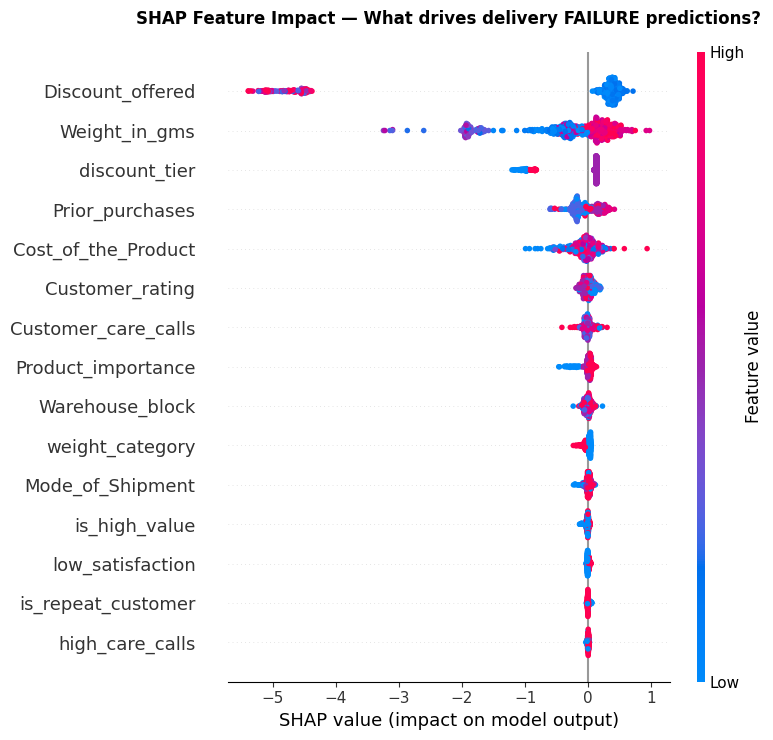

SHAP summary plot saved!


In [6]:
# ── SHAP Explainability ────────────────────────
print("Calculating SHAP values (30-60 seconds)...")

explainer = shap.TreeExplainer(model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values calculated! Shape: {shap_values.shape}")

# ── SHAP Dot Summary Plot ──────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, show=False, plot_type='dot')
plt.title('SHAP Feature Impact — What drives delivery FAILURE predictions?',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\chart8_shap_summary.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

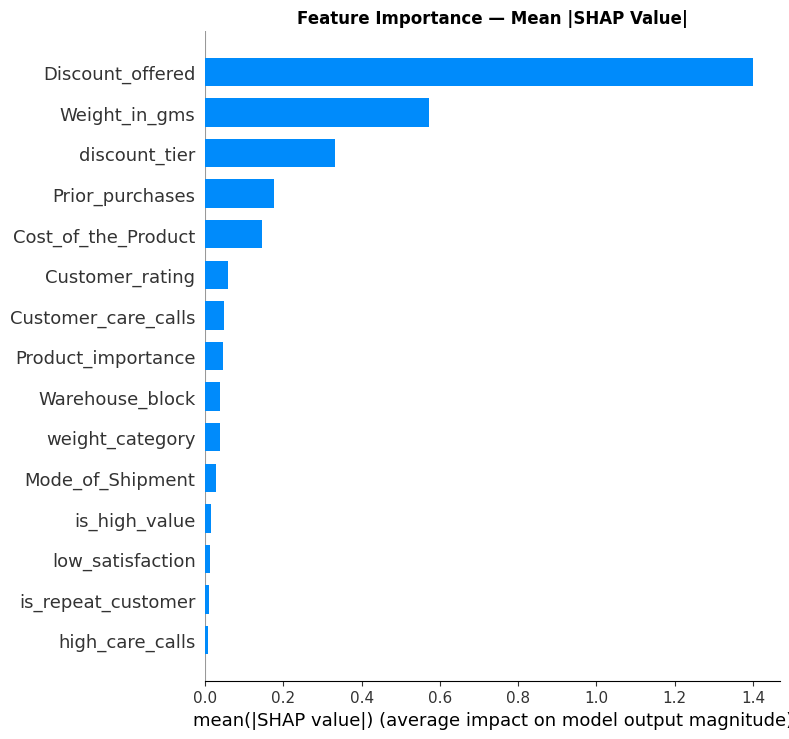

FEATURE IMPORTANCE RANKING (by SHAP):
 rank             feature  mean_shap_value
    1    Discount_offered         1.399196
    2       Weight_in_gms         0.571973
    3       discount_tier         0.330721
    4     Prior_purchases         0.175191
    5 Cost_of_the_Product         0.146111
    6     Customer_rating         0.058501
    7 Customer_care_calls         0.047293
    8  Product_importance         0.046078
    9     Warehouse_block         0.037825
   10     weight_category         0.037705
   11    Mode_of_Shipment         0.028283
   12       is_high_value         0.015980
   13    low_satisfaction         0.013101
   14  is_repeat_customer         0.009884
   15     high_care_calls         0.006315

TOP 3 DRIVERS OF DELIVERY FAILURE:
  #1 Discount_offered (SHAP impact: 1.3992)
  #2 Weight_in_gms (SHAP impact: 0.5720)
  #3 discount_tier (SHAP impact: 0.3307)


In [7]:
# ── SHAP Bar Plot ──────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Feature Importance — Mean |SHAP Value|',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PROCESSED}\\chart9_shap_importance.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Feature importance table ───────────────────
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_shap_value': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap_value', ascending=False).reset_index(drop=True)

importance_df['rank'] = importance_df.index + 1

print("FEATURE IMPORTANCE RANKING (by SHAP):")
print("=" * 50)
print(importance_df[['rank','feature','mean_shap_value']].to_string(index=False))

print("\nTOP 3 DRIVERS OF DELIVERY FAILURE:")
for _, row in importance_df.head(3).iterrows():
    print(f"  #{int(row['rank'])} {row['feature']} "
          f"(SHAP impact: {row['mean_shap_value']:.4f})")